In [1]:
# Handling survival analysis or right-censored data in Numpyro

import jax
import numpyro
numpyro.set_host_device_count(4)
from jax import numpy as jnp, random

import pandas as pd

from numpyro.distributions import RightCensoredDistribution, Weibull, LeftCensoredDistribution, IntervalCensoredDistribution
from numpyro import distributions as dist
from numpyro.infer.hmc import NUTS
from numpyro.infer.mcmc import MCMC



In [2]:
wb = Weibull(1.0, 2.0)

In [3]:
times = jnp.array([0.5, 1.0, 1.5, 2.0])
events = jnp.array([1, 1, 0, 0])  # 1 if event observed, 0 if censored

In [4]:
print(wb.log_prob(times))
print(jnp.log1p(-wb.cdf(times)))

[-0.25       -0.30685282 -1.1513877  -2.6137056 ]
[-0.25      -1.        -2.2499998 -4.0000014]


In [5]:
wbc = RightCensoredDistribution(wb, censored=1 - events)
print(wbc.log_prob(times))

[-0.25       -0.30685282 -2.2499998  -4.0000014 ]


In [6]:
# simulate some data and check parameter retrieval

scale = 1.0
concentration = 2.0
censor_prob = .2
n = 10000

key = random.PRNGKey(0)
key_time, key_censor, key = random.split(key, 3)
wb = Weibull(scale, concentration)
times = wb.sample(key_time, (n,))
is_censored = dist.Bernoulli(censor_prob).sample(key_censor, (n,))

# save to csv
import pandas as pd
df = pd.DataFrame({"times": times, "is_censored": is_censored})
df.to_csv("survival_data.csv", index=False)

In [ ]:
def model(times, is_censored):
    scale = numpyro.sample("scale", dist.HalfNormal(10))
    concentration = numpyro.sample("concentration", dist.HalfNormal(10))
    wb = Weibull(scale, concentration)
    wbc = RightCensoredDistribution(wb, censored=is_censored)
    numpyro.sample("obs", wbc, obs=times)

In [8]:
mcmc = MCMC(NUTS(model), num_warmup=1000, num_samples=2000, num_chains=4)
mcmc.run(key, times, is_censored)
mcmc.print_summary()

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
  concentration      1.99      0.02      1.99      1.96      2.01   4615.46      1.00
          scale      1.12      0.01      1.12      1.11      1.13   7521.93      1.00

Number of divergences: 0


## censored normal

### right censored

In [9]:
# naive model: ignore censoring

def model_naive(x):
    scale = numpyro.sample("scale", dist.HalfNormal(10))
    with numpyro.plate("data", len(x)):
        numpyro.sample("obs", dist.HalfNormal(scale), obs=x)

In [10]:
rng_key = random.PRNGKey(1)
kx, kc = random.split(rng_key)
x_orig = dist.HalfNormal(1).sample(kx, (100,))
tc = dist.HalfNormal(2).sample(kc, (100,))
c = x_orig > tc  # censoring indicator
x = jnp.where(c, tc, x_orig)  # observed data

def model2(x, c):
    scale = numpyro.sample("scale", dist.HalfNormal(10))

    cens_dist = RightCensoredDistribution(dist.HalfNormal(scale), censored=c)
    numpyro.sample("obs", cens_dist, obs=x)

mcmc2 = MCMC(NUTS(model2), num_warmup=1000, num_samples=2000, num_chains=4)
mcmc2.run(rng_key, x, c)
mcmc2.print_summary()

mcmc_naive = MCMC(NUTS(model_naive), num_warmup=1000, num_samples=2000, num_chains=4)
mcmc_naive.run(rng_key, x)
mcmc_naive.print_summary()


  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
     scale      1.04      0.09      1.04      0.89      1.19   2658.07      1.00

Number of divergences: 0


  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
     scale      0.84      0.06      0.83      0.73      0.93   2563.24      1.00

Number of divergences: 0


### left censored

In [11]:
rng_key = random.PRNGKey(1)
kx, kc = random.split(rng_key)
x_orig = dist.HalfNormal(2).sample(kx, (100,))
tc = dist.HalfNormal(1.5).sample(kc, (100,))
c = x_orig < tc  # censoring indicator
x = jnp.where(c, tc, x_orig)  # observed data

def model_left(x, c):
    scale = numpyro.sample("scale", dist.HalfNormal(10))

    cens_dist = LeftCensoredDistribution(dist.HalfNormal(scale), censored=c)
    numpyro.sample("obs", cens_dist, obs=x)

mcmc_left = MCMC(NUTS(model_left), num_warmup=1000, num_samples=2000, num_chains=4)
mcmc_left.run(rng_key, x, c)
mcmc_left.print_summary()

mcmc_naive = MCMC(NUTS(model_naive), num_warmup=1000, num_samples=2000, num_chains=4)
mcmc_naive.run(rng_key, x)
mcmc_naive.print_summary()



  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
     scale      2.07      0.15      2.06      1.82      2.32   2559.29      1.00

Number of divergences: 0


  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
     scale      2.36      0.17      2.35      2.06      2.63   2728.73      1.00

Number of divergences: 0


## Interval censored


In [38]:
rng_key = random.PRNGKey(1)

kx, kl, kr = random.split(rng_key, 3)
x_orig = dist.HalfNormal(2).sample(kx, (1000,))
left = dist.HalfNormal(1).sample(kl, (1000,)) # left censoring
right = dist.HalfNormal(3).sample(kr, (1000,)) # right censoring

x1 = jnp.full(x_orig.shape, jnp.nan) # initialize with nan
x2 = jnp.full(x_orig.shape, jnp.nan)

x1 = jnp.where(x_orig > right, right, x1) # right censored
x2 = jnp.where(x_orig < left, left, x2) # left censored
# interval censored:
x1 = jnp.where((x_orig >= left) & (x_orig <= right), left, x1)
x2 = jnp.where((x_orig >= left) & (x_orig <= right), right, x2)

x = jnp.stack([x1, x2], axis=-1)

df = pd.DataFrame(dict(x=x_orig, left=left, right=right, x1=x1, x2=x2))

def model_interval(x):
    # scale = numpyro.sample("scale", dist.HalfNormal(10))
    scale = numpyro.sample("scale", dist.Uniform(1.0, 10.0))

    # with numpyro.plate("data", len(x)):
    cens_dist = IntervalCensoredDistribution(dist.HalfNormal(scale))

    numpyro.sample("obs", cens_dist, obs=x)

init_params = {"scale": jnp.full((4,), jnp.array(2.0))}
init_params = None
mcmc_interval = MCMC(NUTS(model_interval), num_warmup=1000, num_samples=2000, num_chains=4)
mcmc_interval.run(rng_key, x, init_params=init_params)
mcmc_interval.print_summary()


  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
     scale      3.51      0.85      3.42      2.54      4.69       nan 2413800.75

Number of divergences: 8000


In [42]:
scales = jnp.linspace(0.1, 5, 1000)
lp = jax.vmap(lambda s: IntervalCensoredDistribution(dist.HalfNormal(s)).log_prob(x).sum())(scales)

In [43]:
scales[jnp.argmax(lp)]

Array(1.9981982, dtype=float32)

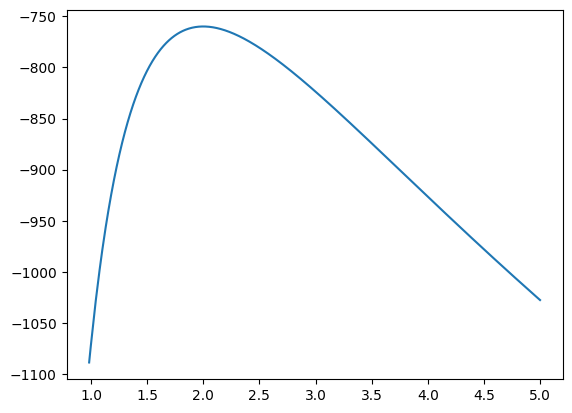

In [44]:
import matplotlib.pyplot as plt
plt.plot(scales, lp)

In [22]:
df

,x,left,right,x1,x2
0,1.063875,0.243920,0.436060,0.436060,NaN
1,1.446034,0.122870,2.275707,0.122870,2.275707
2,1.814514,0.763310,1.996000,0.763310,1.996000
3,1.900905,0.931107,0.588999,0.588999,NaN
4,3.874814,1.183018,0.098656,0.098656,NaN
...,...,...,...,...,...
495,2.613985,0.182948,0.873615,0.873615,NaN
496,2.010287,0.709012,1.107641,1.107641,NaN
497,0.976686,0.705287,1.619237,0.705287,1.619237
498,4.731783,0.812705,1.999299,1.999299,NaN
